# Prétraitement du dataset Diabète – Sprint 1

Ce notebook couvre :
1. Lecture et inspection des données
2. Prétraitement initial (regroupement des classes)
3. Séparation train / validation / test
4. Normalisation des features
5. Typage des variables
6. Nettoyage des doublons et gestion des valeurs manquantes
7. Analyse exploratoire quantitative

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Lecture du dataset
On charge le fichier CSV et on affiche un aperçu ainsi que les informations générales.

In [66]:
def read_data(file_path="../data/diabetes_binary_health_indicators_BRFSS2015.csv"):
    try:
        df = pd.read_csv(file_path)
        print("Aperçu des 5 premières lignes :")
        print(df.head())
        print("\nInformations générales :")
        print(df.info())
        print("\nValeurs manquantes par colonne :")
        print(df.isnull().sum())
        df.to_parquet("test_index_false.parquet", index=False)
        return df
    except FileNotFoundError:
        print(f"Erreur : le fichier {file_path} n'a pas été trouvé.")
        return None
print(f"Nombre de lignes avant suppression des doublons : {len(df)}")

df = read_data()

Nombre de lignes avant suppression des doublons : 229474
Aperçu des 5 premières lignes :
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Se

## Prétraitement initial
- Regroupement des classes : 0 = no diabète ou prediabète, 1 = diabète
- Séparation des features (X) et de la cible (y)

In [67]:
def separate_data(df):
    X = df.drop("Diabetes_binary", axis=1)
    y = df["Diabetes_binary"]
    return X, y

if df is not None:
    X, y = separate_data(df)
    print("Distribution des classes :")
    print(y.value_counts())

Distribution des classes :
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


## Séparation Train / Validation / Test
- 70% train
- 15% validation
- 15% test
- Stratification pour garder la proportion des classes

In [68]:
if df is not None:
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    
    print("Taille train :", X_train.shape)
    print("Taille validation :", X_val.shape)
    print("Taille test :", X_test.shape)


Taille train : (177576, 21)
Taille validation : (38052, 21)
Taille test : (38052, 21)


## Normalisation des features
- Standardisation : moyenne=0, écart type=1
- Fit sur le train, transform sur validation et test

In [69]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Normalisation effectuée. Exemple :")
print(X_train_scaled[:5])


Normalisation effectuée. Exemple :
[[-0.86692187  1.16486098  0.19770711 -0.96495671  1.12096684 -0.20493045
  -0.32292458  0.56632089  0.75853319  0.48181784 -0.24224481  0.22728907
  -0.30393876 -0.47881617 -0.42993769 -0.48668106 -0.44917051 -0.88946385
   1.30094063  0.96354187 -0.02582259]
 [-0.86692187  1.16486098  0.19770711 -0.8136217   1.12096684 -0.20493045
  -0.32292458  0.56632089  0.75853319  0.48181784  4.12805538  0.22728907
  -0.30393876 -0.47881617 -0.42993769 -0.14262177  2.22632603 -0.88946385
  -0.33821355 -1.06446483  0.93882906]
 [-0.86692187 -0.85847154  0.19770711 -0.20828165 -0.89208705 -0.20493045
  -0.32292458  0.56632089 -1.31833387  0.48181784  4.12805538  0.22728907
  -0.30393876 -1.41464125 -0.42993769 -0.48668106 -0.44917051  1.12427278
  -0.01038271  0.96354187  0.45650324]
 [ 1.15350648 -0.85847154  0.19770711 -0.05694664  1.12096684 -0.20493045
  -0.32292458  0.56632089  0.75853319  0.48181784 -0.24224481  0.22728907
  -0.30393876 -0.47881617  0.51255

## Typage des variables
- Vérification et conversion des types de variables si nécessaire
- S'assurer que les variables catégorielles, booléennes et numériques ont le bon type

In [70]:
if df is not None:
   
    float_cols = [
        "GenHlth", "MentHlth", "PhysHlth", "DiffWalk", "BMI", "Age", "Education", "Income"
    ]

    binary_cols = [col for col in df.columns if col not in float_cols]

    # Conversion en float
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

    # Conversion en Binaire
    for col in binary_cols:
        df[col] = df[col].apply(lambda x: True if x not in [0, '0', False, 'False', None, np.nan] else False)
        df[col] = df[col].astype(bool)

    print("\nTypes après conversion :")
    print(df.dtypes)



Types après conversion :
Diabetes_binary            bool
HighBP                     bool
HighChol                   bool
CholCheck                  bool
BMI                     float64
Smoker                     bool
Stroke                     bool
HeartDiseaseorAttack       bool
PhysActivity               bool
Fruits                     bool
Veggies                    bool
HvyAlcoholConsump          bool
AnyHealthcare              bool
NoDocbcCost                bool
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                        bool
Age                     float64
Education               float64
Income                  float64
dtype: object


## Nettoyage des doublons et gestion des valeurs manquantes
- Suppression des doublons
- Gestion des valeurs manquantes (imputation ou suppression selon le cas)

In [71]:
print(f"Nombre de lignes avant suppression des doublons : {len(df)}")

if df is not None:
    # Suppression des doublons
    df = df.drop_duplicates()
    print(f"Nombre de lignes après suppression des doublons : {len(df)}")

    # Affichage des valeurs manquantes
    print("\nValeurs manquantes par colonne :")
    print(df.isnull().sum())

    # Suppression des lignes avec trop de valeurs manquantes (exemple: plus de 50% de colonnes)
    seuil = int(0.5 * df.shape[1])
    df = df.dropna(thresh=seuil)

    # Imputation des valeurs manquantes restantes (par la médiane pour les floats, mode pour les binaires)
    for col in df.columns:
        if df[col].dtype == float:
            df[col] = df[col].fillna(df[col].median())
        elif df[col].dtype == int or df[col].dtype == 'int8' or df[col].dtype == bool:
            df[col] = df[col].fillna(df[col].mode()[0])
    print("\nValeurs manquantes après traitement :")
    print(df.isnull().sum())

Nombre de lignes avant suppression des doublons : 253680
Nombre de lignes après suppression des doublons : 229474

Valeurs manquantes par colonne :
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Valeurs manquantes après traitement :
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity        

## Analyse exploratoire quantitative
- Statistiques descriptives (moyenne, médiane, écart-type, min, max)
- Distribution des variables
- Corrélations entre variables
- Visualisation des résultats

Statistiques descriptives :
                 BMI        GenHlth       MentHlth       PhysHlth  \
count  229474.000000  229474.000000  229474.000000  229474.000000   
mean       28.687507       2.601820       3.509866       4.681219   
std         6.789204       1.064962       7.717643       9.050877   
min        12.000000       1.000000       0.000000       0.000000   
25%        24.000000       2.000000       0.000000       0.000000   
50%        27.000000       3.000000       0.000000       0.000000   
75%        32.000000       3.000000       2.000000       4.000000   
max        98.000000       5.000000      30.000000      30.000000   

            DiffWalk            Age      Education         Income  
count  229474.000000  229474.000000  229474.000000  229474.000000  
mean        0.185751       8.085068       4.979741       5.888615  
std         0.388906       3.094451       0.992989       2.092888  
min         0.000000       1.000000       1.000000       1.000000  
25%       

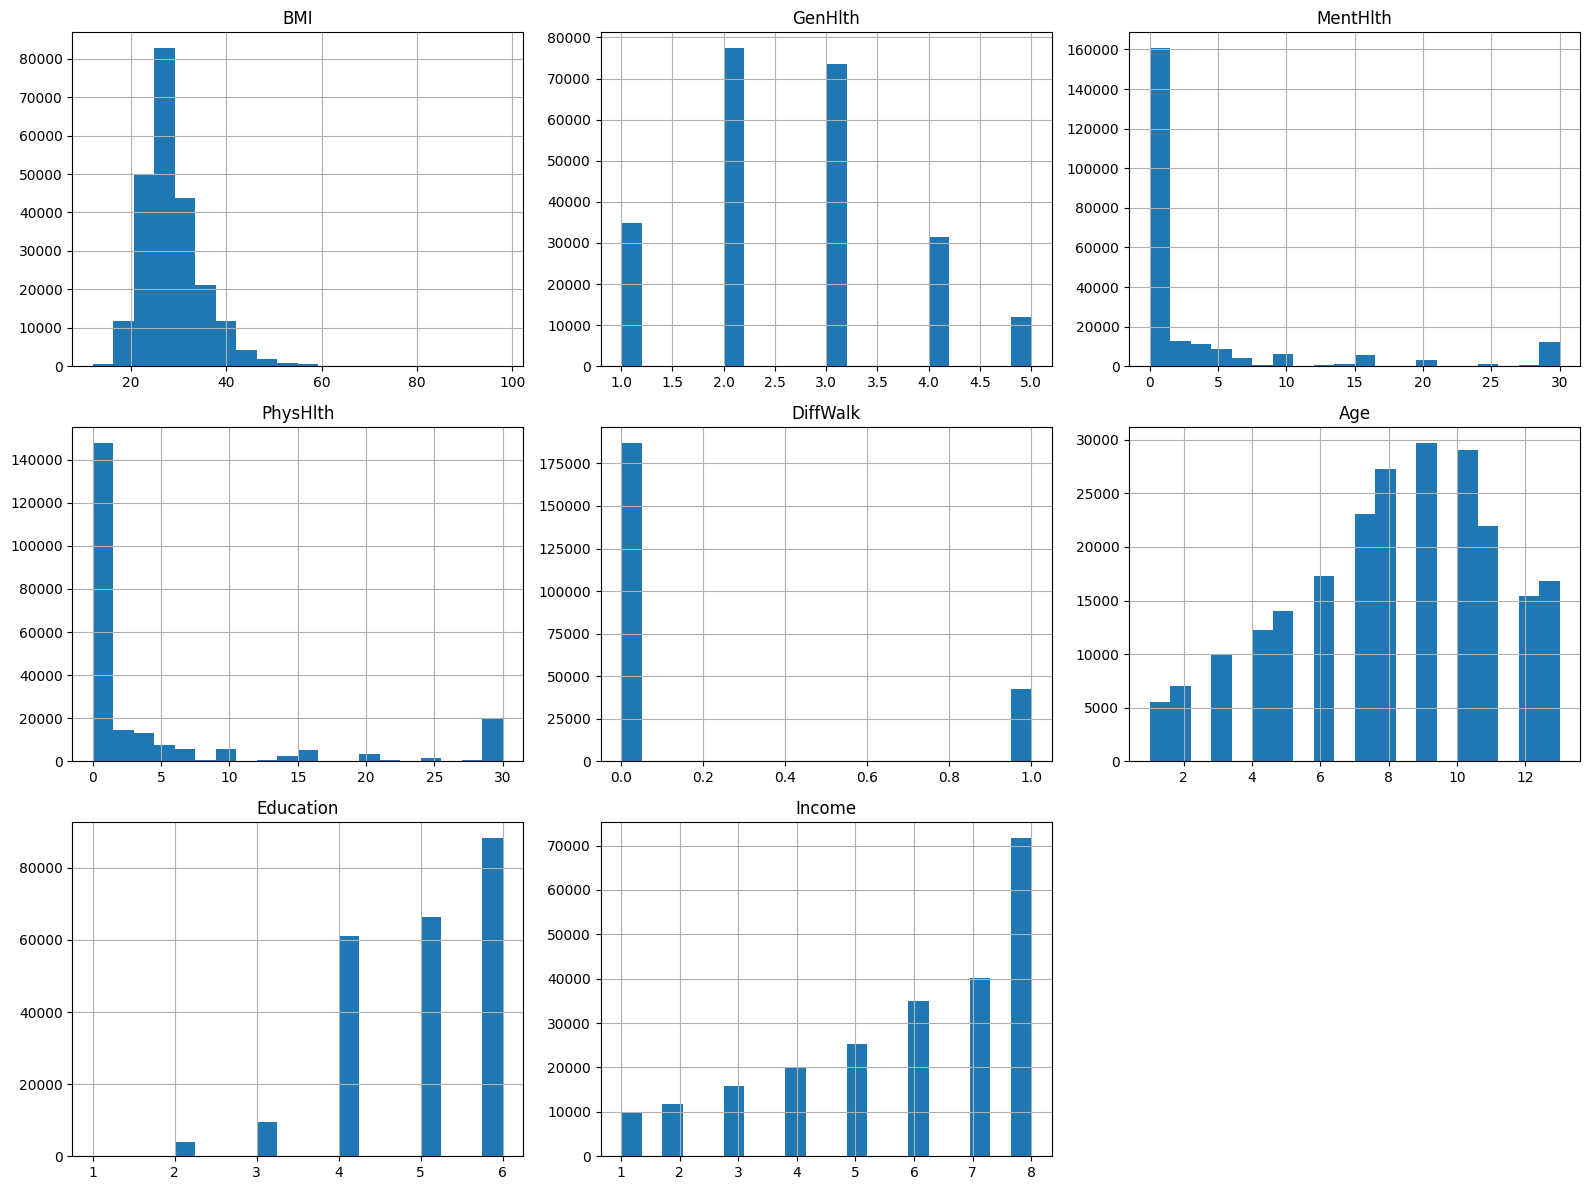


Matrice de corrélation :
                      Diabetes_binary    HighBP  HighChol  CholCheck  \
Diabetes_binary              1.000000  0.254318  0.194944   0.072523   
HighBP                       0.254318  1.000000  0.283963   0.111259   
HighChol                     0.194944  0.283963  1.000000   0.094772   
CholCheck                    0.072523  0.111259  0.094772   1.000000   
BMI                          0.205086  0.194218  0.089734   0.042487   
Smoker                       0.045504  0.074264  0.074583  -0.003721   
Stroke                       0.099193  0.124558  0.089375   0.027955   
HeartDiseaseorAttack         0.168213  0.201443  0.176446   0.050086   
PhysActivity                -0.100404 -0.104382 -0.063443  -0.004555   
Fruits                      -0.024805 -0.019467 -0.026257   0.017860   
Veggies                     -0.041734 -0.042994 -0.027399  -0.000653   
HvyAlcoholConsump           -0.065950 -0.014178 -0.019057  -0.020975   
AnyHealthcare                0.025331 

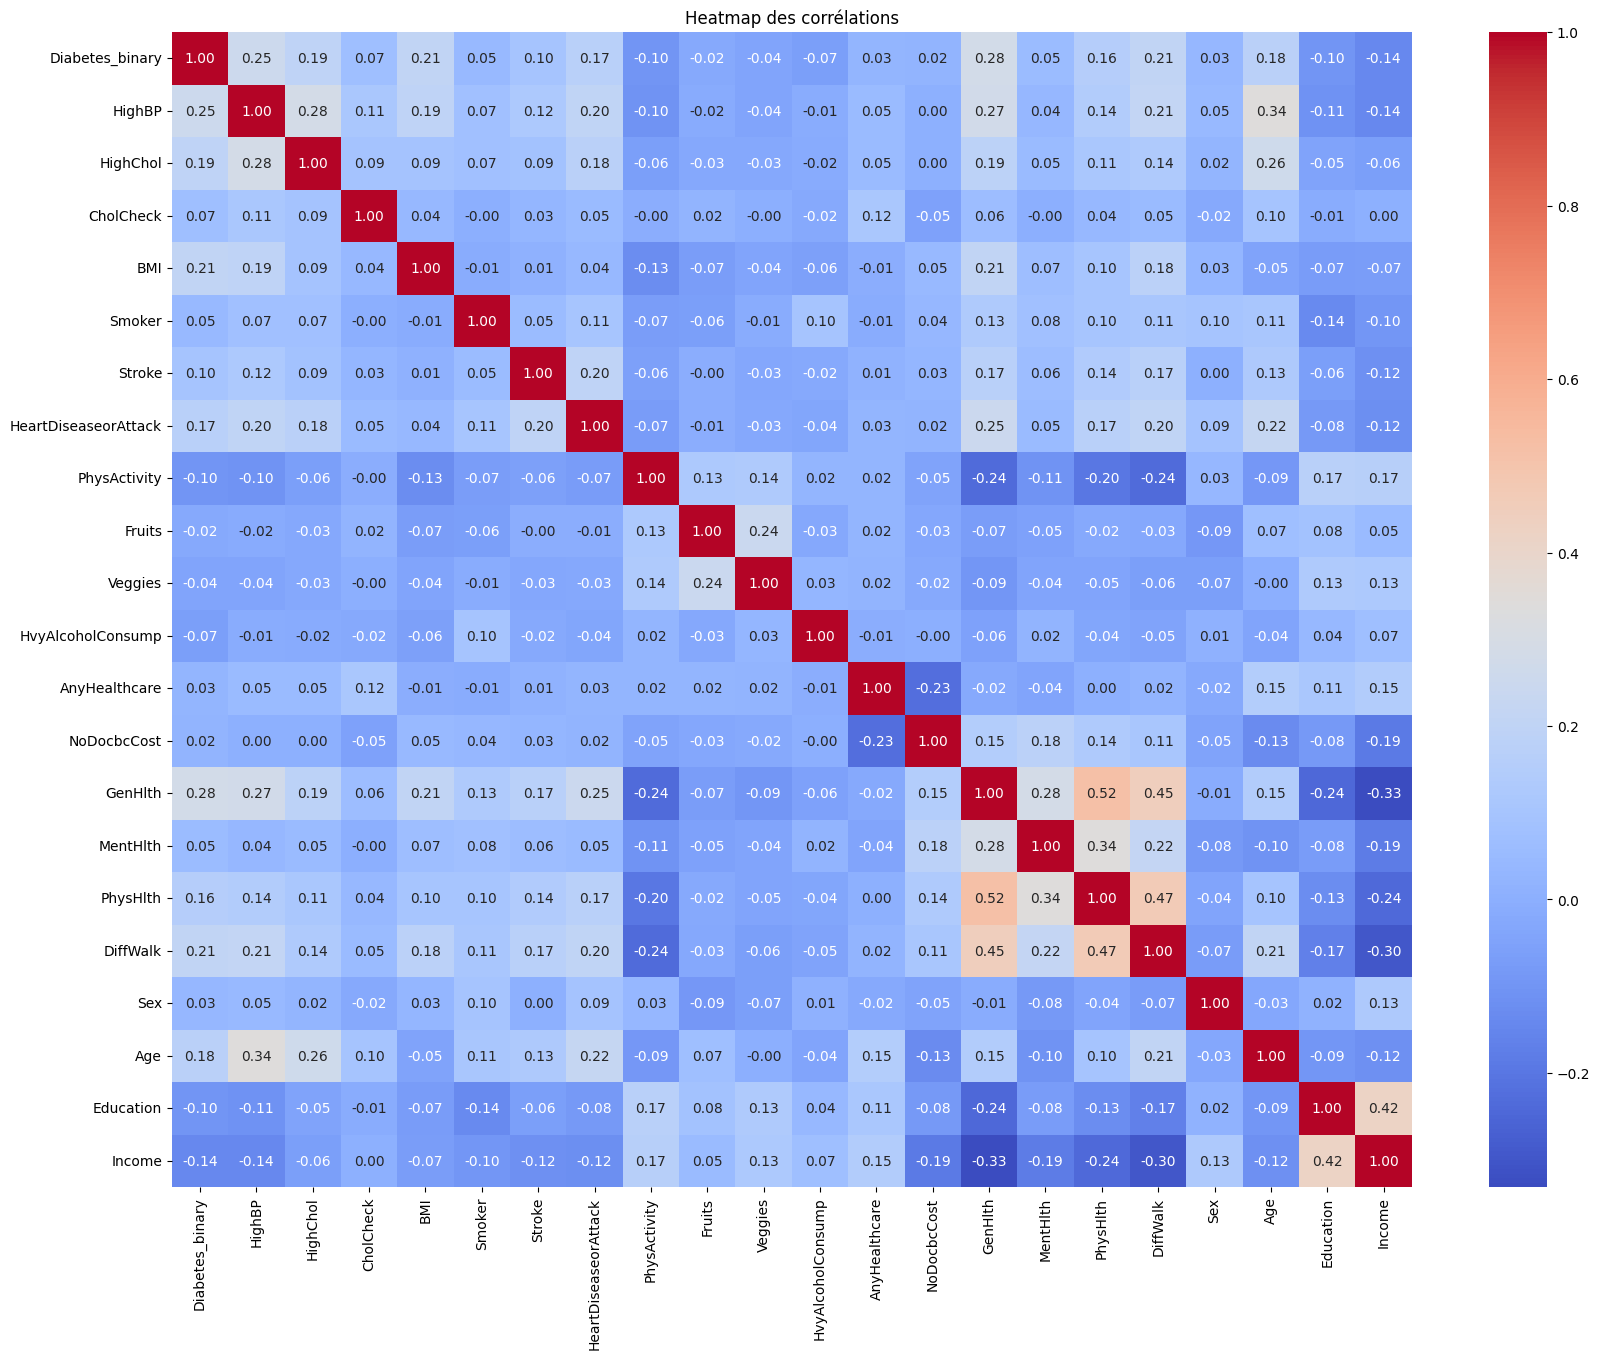

In [72]:
# Analyse exploratoire quantitative
if df is not None:
    # Statistiques descriptives
    print("Statistiques descriptives :")
    print(df.describe())

    # Distribution des variables (histogrammes)
    import matplotlib.pyplot as plt
    df.hist(figsize=(16, 12), bins=20)
    plt.tight_layout()
    plt.show()

    # Corrélations entre variables
    print("\nMatrice de corrélation :")
    print(df.corr())
    plt.figure(figsize=(20, 15))
    import seaborn as sns
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Heatmap des corrélations")
    plt.show()